<a href="https://colab.research.google.com/github/heavyrainseo/deeplearning/blob/main/test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diamonds Linear Regression

In [1]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 37.7 MB/s eta 0:00:00


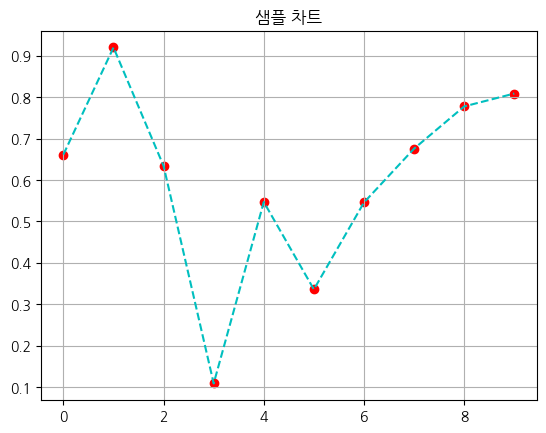

In [8]:
import numpy as np

x = np.random.random(10)

import matplotlib.pyplot as plt
import koreanize_matplotlib

plt.title('샘플 차트')
plt.scatter(list(range(len(x))), x, color='red')
plt.plot(x, 'c--')
plt.grid()

In [ ]:
import seaborn as sns
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
dm = sns.load_dataset('diamonds')

duckdb.sql("describe select * from dm").show()

┌─────────────┬──────────────────────────────────────────────────────────────┬─────────┬─────────┬─────────┬─────────┐
│ column_name │                         column_type                          │  null   │   key   │ default │  extra  │
│   varchar   │                           varchar                            │ varchar │ varchar │ varchar │ varchar │
├─────────────┼──────────────────────────────────────────────────────────────┼─────────┼─────────┼─────────┼─────────┤
│ carat       │ DOUBLE                                                       │ YES     │ NULL    │ NULL    │ NULL    │
│ cut         │ ENUM('Ideal', 'Premium', 'Very Good', 'Good', 'Fair')        │ YES     │ NULL    │ NULL    │ NULL    │
│ color       │ ENUM('D', 'E', 'F', 'G', 'H', 'I', 'J')                      │ YES     │ NULL    │ NULL    │ NULL    │
│ clarity     │ ENUM('IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1') │ YES     │ NULL    │ NULL    │ NULL    │
│ depth       │ DOUBLE                          

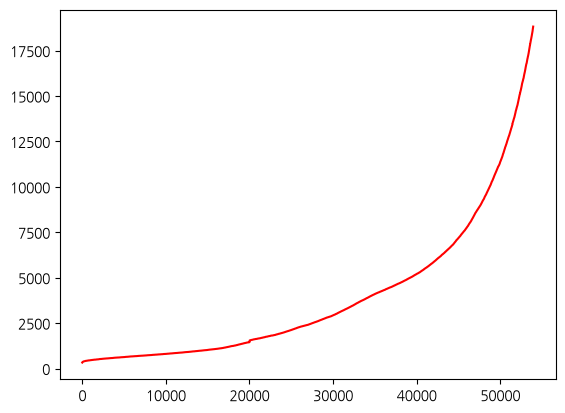

In [ ]:
df = duckdb.sql("select carat, price from dm").df()
df_copy = df.sort_values('price').copy()
plt.plot(range(len(df_copy)), df_copy.price, 'r-')

<Axes: >

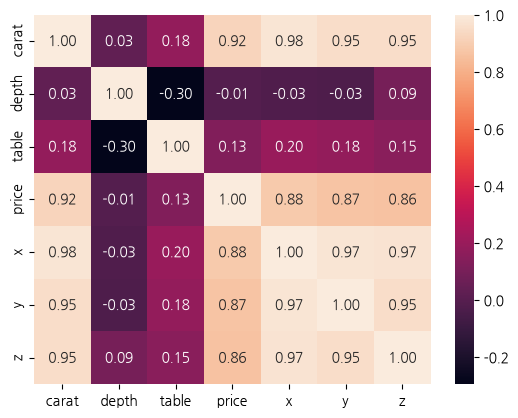

In [ ]:
sns.heatmap(dm.corr(numeric_only=True), annot=True, fmt='.2f')

## 상관계수로 a와 b 구하기

In [ ]:
a = df.corr().iloc[1,0] * df['price'].std()/df['carat'].std()
b = df['price'].mean() - a * df['carat'].mean()
a, b

(np.float64(7756.425617968368), np.float64(-2256.36058004535))

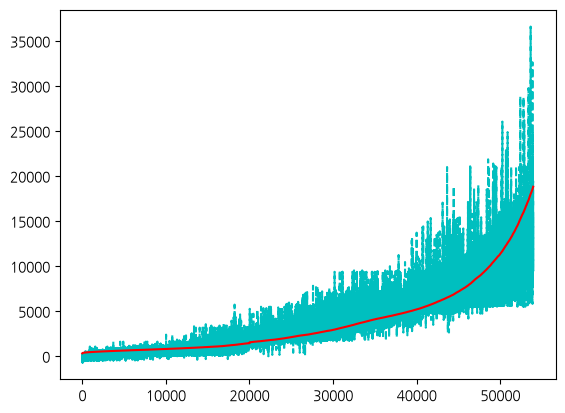

In [ ]:
df['pred'] = a*df.carat + b

plt.plot(list(range(len(df))), df.sort_values('price').pred, 'c--')
plt.plot(list(range(len(df))),df.sort_values('price').price, 'r-')


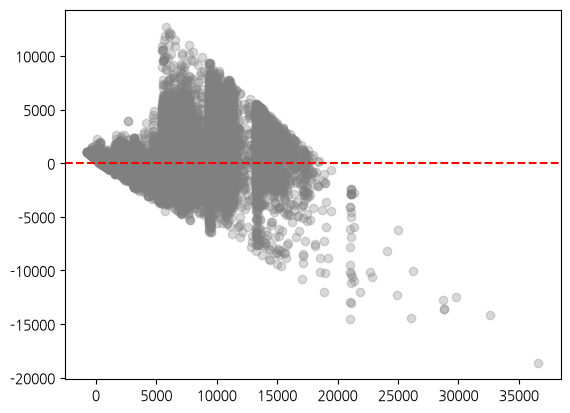

In [ ]:
plt.scatter(df.pred, df.price - df.pred, color='gray', alpha=0.3)
plt.axhline(0, color='red', linestyle='--')

## Tensorflow로 구하기

In [ ]:
x = dm['carat']
y = dm['price']

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [ ]:
model = Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(1, activation='linear'))

model.compile(loss='mse', optimizer='sgd')
print(model.get_weights())
model.summary()

[array([[-1.2460161]], dtype=float32), array([0.], dtype=float32)]


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
esc = EarlyStopping(patience=10, monitor='val_loss')

hist = model.fit(x, y, validation_split=.2, callbacks=[esc], epochs=10000, batch_size=64, verbose=0)
model.get_weights()

[array([[7753.4014]], dtype=float32), array([-2124.1016], dtype=float32)]

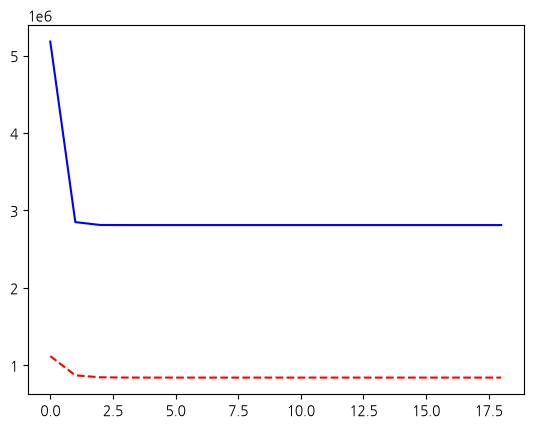

In [ ]:
plt.plot(hist.history['loss'], 'b-')
plt.plot(hist.history['val_loss'], 'r--')

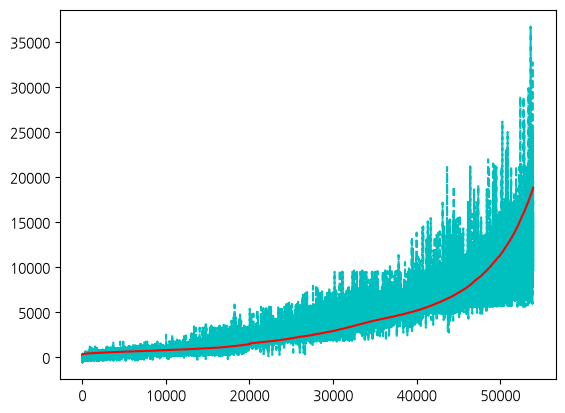

In [ ]:
plt.plot(list(range(len(df))), result.sort_values('price').pred, 'c--')
plt.plot(list(range(len(df))), result.sort_values('price').price, 'r-')


1686/1686 ━━━━━━━━━━━━━━━━━━━━ 0s 128us/step


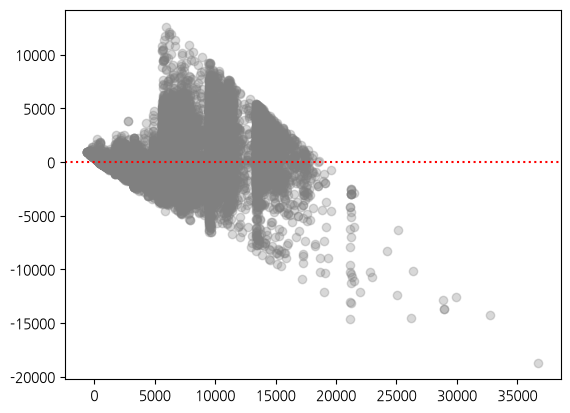

In [ ]:
result = dm[['carat', 'price']].copy()
result['pred'] = model.predict(result.carat)

residual = result['price'] - result['pred']

plt.scatter(result['pred'], residual, color='gray', alpha=.3)
plt.axhline(0, color='red', linestyle='dotted')

# Titanic Logistic Regression

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
tt = sns.load_dataset('titanic')
tt.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [ ]:
tt.age = tt.age.fillna(tt.age.median())
tt.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [ ]:
df = tt[['sex','age','survived']].copy()
df = pd.get_dummies(df, columns=['sex'], dtype=int)
df.head()

,age,survived,sex_female,sex_male
0,22.0,0,0,1
1,38.0,1,1,0
2,26.0,1,1,0
3,35.0,1,1,0
4,35.0,0,0,1


<Axes: >

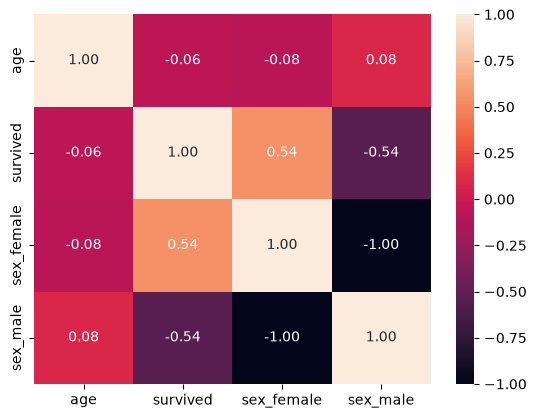

In [ ]:
sns.heatmap(df.corr(), annot=True, fmt='.2f')

In [ ]:
x = df[['sex_female', 'sex_male', 'age']].copy()
y = df[['survived']].copy()
x, y

(     sex_female  sex_male   age
 0             0         1  22.0
 1             1         0  38.0
 2             1         0  26.0
 3             1         0  35.0
 4             0         1  35.0
 ..          ...       ...   ...
 886           0         1  27.0
 887           1         0  19.0
 888           1         0  28.0
 889           0         1  26.0
 890           0         1  32.0
 
 [891 rows x 3 columns],
      survived
 0           0
 1           1
 2           1
 3           1
 4           0
 ..        ...
 886         0
 887         1
 888         0
 889         1
 890         0
 
 [891 rows x 1 columns])

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

I0000 00:00:1791110815.098273   28837 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791110815.143376   28837 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791110817.324937   28837 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [ ]:
model = Sequential()
model.add(Input(shape=(3,)))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print(model.get_weights())
model.summary()

[array([[1.2114261 ],
       [1.0331873 ],
       [0.18027735]], dtype=float32), array([0.], dtype=float32)]


E0000 00:00:1791110821.727133   28837 cuda_platform.cc:57] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
=== Source Location Trace: ===
external/xla/xla/stream_executor/cuda/cuda_status.cc:50



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

esc = EarlyStopping(patience=10, monitor='val_loss')
history = model.fit(x, y, validation_split=0.2, callbacks=[esc], epochs=10000, batch_size=32, verbose=0)
model.get_weights()

[array([[ 2.1817994 ],
        [-0.28168538],
        [-0.01007552]], dtype=float32),
 array([-0.783417], dtype=float32)]

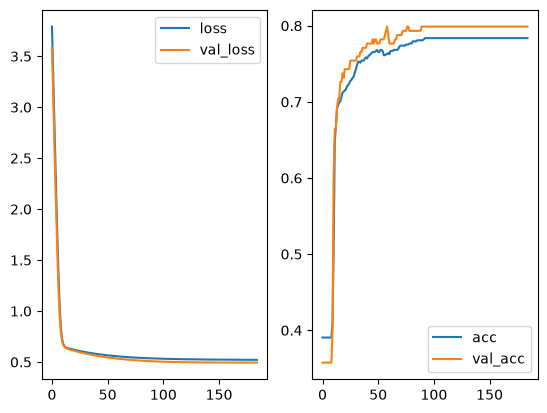

In [ ]:
ax = plt.subplot(1,2,1)
ax.plot(history.history['loss'], label='loss')
ax.plot(history.history['val_loss'], label='val_loss')
ax.legend()
ax = plt.subplot(1,2,2)
ax.plot(history.history['accuracy'], label='acc')
ax.plot(history.history['val_accuracy'], label='val_acc')
ax.legend()


In [ ]:
model.evaluate(x, y)

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7868 - loss: 0.5157 


[0.5156691670417786, 0.7867564558982849]

In [ ]:
res = pd.DataFrame({'survived':y.survived, 'predict':np.round(model.predict(x).flatten(),0)})
res.sum()


 1/28 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


survived    342.0
predict     314.0
dtype: float64

# iris softmax

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

I0000 00:00:1791117389.137094    4380 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791117402.652475    4380 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791117412.355529    4380 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [ ]:
iris = sns.load_dataset('iris')
iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [ ]:
df = pd.get_dummies(iris, columns=['species'], dtype=int)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species_setosa,species_versicolor,species_virginica
0,5.1,3.5,1.4,0.2,1,0,0
1,4.9,3.0,1.4,0.2,1,0,0
2,4.7,3.2,1.3,0.2,1,0,0
3,4.6,3.1,1.5,0.2,1,0,0
4,5.0,3.6,1.4,0.2,1,0,0


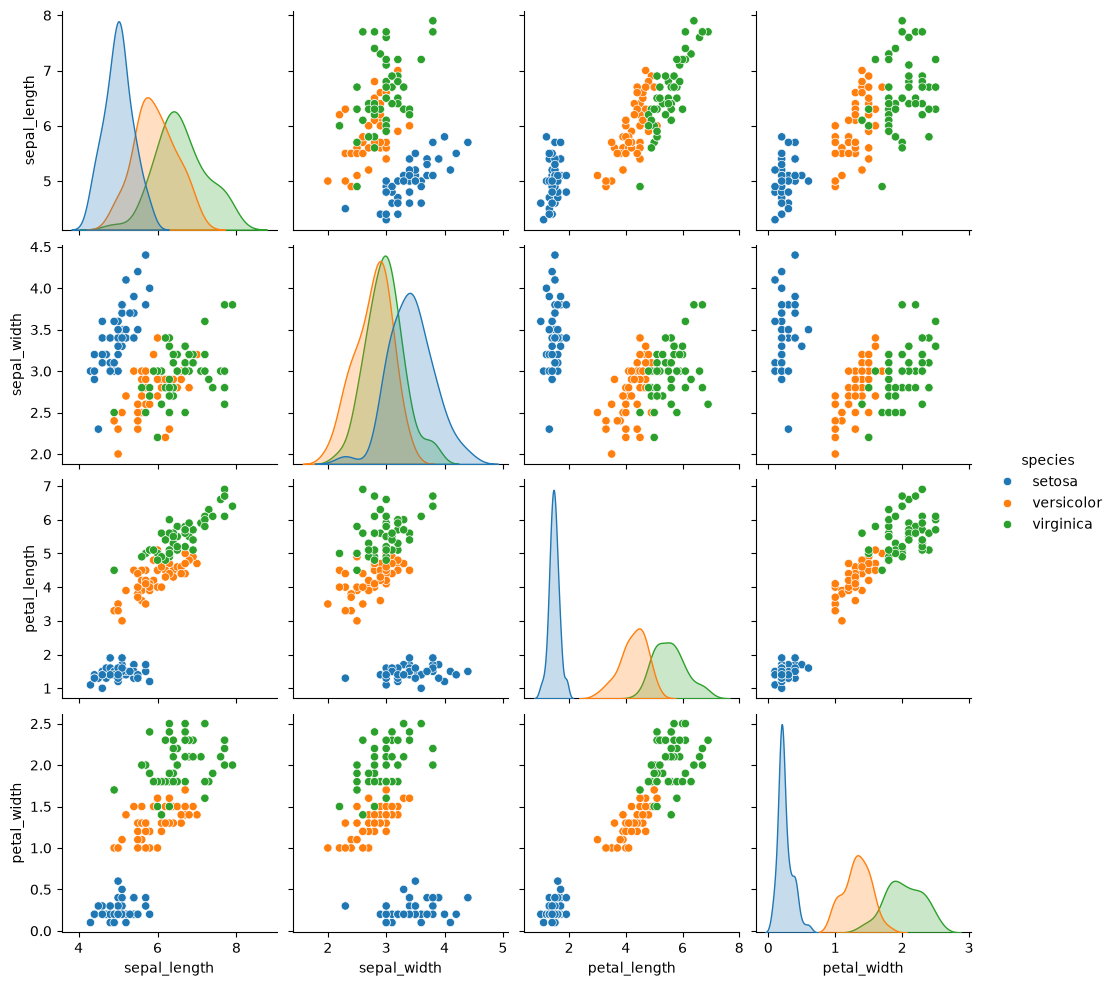

In [ ]:
sns.pairplot(iris, hue='species')

In [ ]:
x = df.iloc[:, :4]
y = df.iloc[:, 4:]
x, y

(     sepal_length  sepal_width  petal_length  petal_width
 0             5.1          3.5           1.4          0.2
 1             4.9          3.0           1.4          0.2
 2             4.7          3.2           1.3          0.2
 3             4.6          3.1           1.5          0.2
 4             5.0          3.6           1.4          0.2
 ..            ...          ...           ...          ...
 145           6.7          3.0           5.2          2.3
 146           6.3          2.5           5.0          1.9
 147           6.5          3.0           5.2          2.0
 148           6.2          3.4           5.4          2.3
 149           5.9          3.0           5.1          1.8
 
 [150 rows x 4 columns],
      species_setosa  species_versicolor  species_virginica
 0                 1                   0                  0
 1                 1                   0                  0
 2                 1                   0                  0
 3                 1     

In [ ]:
model = Sequential()
model.add(Input(shape=(4,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(3, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,979 (11.64 KB)

 Trainable params: 2,979 (11.64 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

esc = EarlyStopping(patience=10, monitor='val_loss')
history = model.fit(x, y, callbacks=[esc], validation_split=0.2, epochs=1000, batch_size=16, verbose=0)

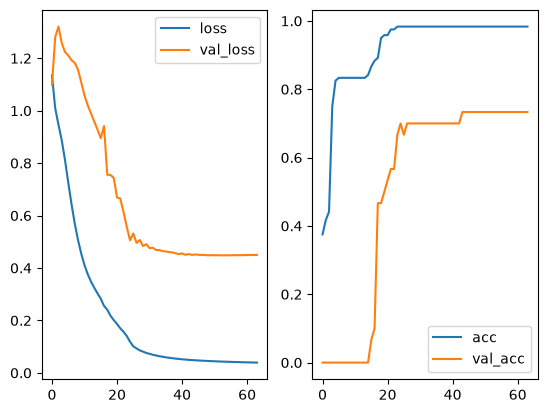

In [ ]:
ax = plt.subplot(1,2,1)
ax.plot(history.history['loss'], label='loss')
ax.plot(history.history['val_loss'], label='val_loss')
ax.legend()

ax = plt.subplot(1,2,2)
ax.plot(history.history['accuracy'], label='acc')
ax.plot(history.history['val_accuracy'], label='val_acc')
ax.legend()


In [ ]:
model.evaluate(x,y)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9333 - loss: 0.1194    


[0.11940544098615646, 0.9333333373069763]

In [ ]:
res = pd.DataFrame({'y':y.to_numpy().argmax(axis=1),'pred':model.predict(x).argmax(axis=1)})
print(f'correct : {res[res.y==res.pred].y.count()}, incorrect : {res[res.y!=res.pred].y.count()}')
res[res.y != res.pred]


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
correct : 140, incorrect : 10


,y,pred
83,1,2
110,2,1
123,2,1
126,2,1
127,2,1
129,2,1
131,2,1
133,2,1
138,2,1
141,2,1


In [ ]:
pd.from_dummies(y)

,
0,species_setosa
1,species_setosa
2,species_setosa
3,species_setosa
4,species_setosa
...,...
145,species_virginica
146,species_virginica
147,species_virginica
148,species_virginica
